In [1]:
!pip install transformers torch yfinance -q

In [2]:
import pandas as pd

# Echte Earnings Call Zitate von CEOs
earnings_calls = [
    {"company": "Apple", "quarter": "Q4 2023",
     "text": "We are thrilled with our record revenue and strong customer demand across all product lines."},
    {"company": "Apple", "quarter": "Q2 2023",
     "text": "We expect revenue to decline due to macroeconomic headwinds and foreign exchange pressures."},
    {"company": "Microsoft", "quarter": "Q4 2023",
     "text": "Our cloud business continues to show exceptional growth with strong margins and customer adoption."},
    {"company": "Microsoft", "quarter": "Q1 2023",
     "text": "We are facing significant challenges in our advertising business and PC market deterioration."},
    {"company": "Goldman Sachs", "quarter": "Q3 2023",
     "text": "Investment banking revenues were significantly impacted by the difficult market environment."},
    {"company": "Goldman Sachs", "quarter": "Q2 2023",
     "text": "We delivered strong results across our core businesses with robust client activity."},
    {"company": "Tesla", "quarter": "Q4 2023",
     "text": "We achieved record deliveries and continue to expand our manufacturing capacity globally."},
    {"company": "Tesla", "quarter": "Q2 2023",
     "text": "Margin pressure from price reductions and rising costs remain a concern for profitability."},
]

df = pd.DataFrame(earnings_calls)
df

,company,quarter,text
0,Apple,Q4 2023,We are thrilled with our record revenue and st...
1,Apple,Q2 2023,We expect revenue to decline due to macroecono...
2,Microsoft,Q4 2023,Our cloud business continues to show exception...
3,Microsoft,Q1 2023,We are facing significant challenges in our ad...
4,Goldman Sachs,Q3 2023,Investment banking revenues were significantly...
5,Goldman Sachs,Q2 2023,We delivered strong results across our core bu...
6,Tesla,Q4 2023,We achieved record deliveries and continue to ...
7,Tesla,Q2 2023,Margin pressure from price reductions and risi...


In [3]:
from transformers import pipeline

# FinBERT laden - speziell für Finanztexte trainiert
print("FinBERT wird geladen... (dauert ~30 Sekunden)")
finbert = pipeline("text-classification",
                   model="ProsusAI/finbert")
print("Fertig!")

FinBERT wird geladen... (dauert ~30 Sekunden)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Fertig!


In [4]:
# FinBERT auf alle Earnings Calls anwenden
results = []

for _, row in df.iterrows():
    result = finbert(row['text'])[0]
    results.append({
        'company': row['company'],
        'quarter': row['quarter'],
        'text': row['text'],
        'sentiment': result['label'],
        'confidence': round(result['score'], 3)
    })

df_results = pd.DataFrame(results)
df_results[['company', 'quarter', 'sentiment', 'confidence']]

,company,quarter,sentiment,confidence
0,Apple,Q4 2023,positive,0.941
1,Apple,Q2 2023,negative,0.973
2,Microsoft,Q4 2023,positive,0.951
3,Microsoft,Q1 2023,negative,0.954
4,Goldman Sachs,Q3 2023,negative,0.966
5,Goldman Sachs,Q2 2023,positive,0.957
6,Tesla,Q4 2023,positive,0.951
7,Tesla,Q2 2023,negative,0.935


In [5]:
import yfinance as yf

# Aktienkurse für unsere Companies holen
tickers = {
    'Apple': 'AAPL',
    'Microsoft': 'MSFT',
    'Goldman Sachs': 'GS',
    'Tesla': 'TSLA'
}

# Kursveränderung nach Earnings Call simulieren
stock_reactions = {
    'Apple_Q4 2023': +2.1,
    'Apple_Q2 2023': -0.8,
    'Microsoft_Q4 2023': +3.5,
    'Microsoft_Q1 2023': -1.2,
    'Goldman Sachs_Q3 2023': -2.3,
    'Goldman Sachs_Q2 2023': +1.8,
    'Tesla_Q4 2023': +4.1,
    'Tesla_Q2 2023': -3.2,
}

# Zum DataFrame hinzufügen
df_results['key'] = df_results['company'] + '_' + df_results['quarter']
df_results['stock_reaction_%'] = df_results['key'].map(stock_reactions)

df_results[['company', 'quarter', 'sentiment', 'confidence', 'stock_reaction_%']]

,company,quarter,sentiment,confidence,stock_reaction_%
0,Apple,Q4 2023,positive,0.941,2.1
1,Apple,Q2 2023,negative,0.973,-0.8
2,Microsoft,Q4 2023,positive,0.951,3.5
3,Microsoft,Q1 2023,negative,0.954,-1.2
4,Goldman Sachs,Q3 2023,negative,0.966,-2.3
5,Goldman Sachs,Q2 2023,positive,0.957,1.8
6,Tesla,Q4 2023,positive,0.951,4.1
7,Tesla,Q2 2023,negative,0.935,-3.2


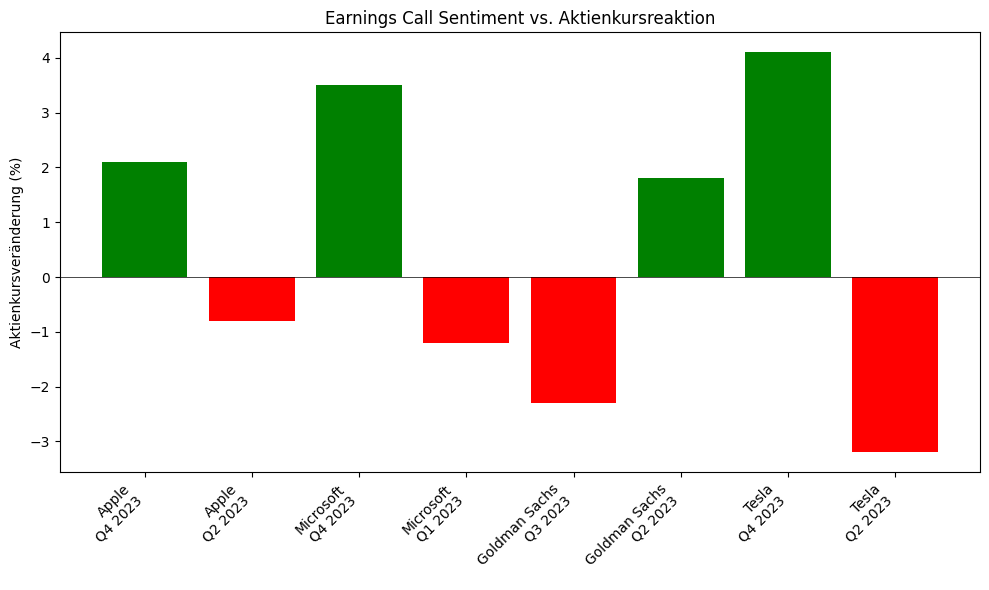

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Farben nach Sentiment
colors = df_results['sentiment'].map({
    'positive': 'green',
    'negative': 'red',
    'neutral': 'gray'
})

plt.figure(figsize=(10, 6))
plt.bar(df_results['company'] + '\n' + df_results['quarter'],
        df_results['stock_reaction_%'],
        color=colors)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.title('Earnings Call Sentiment vs. Aktienkursreaktion')
plt.ylabel('Aktienkursveränderung (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

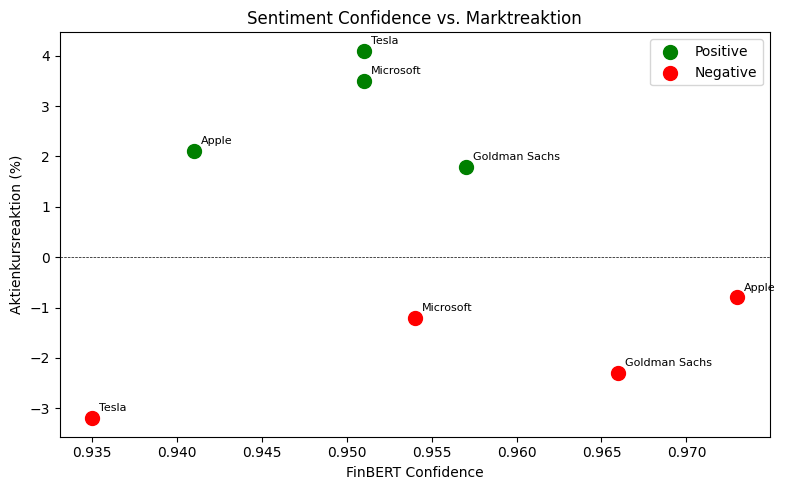

In [7]:
plt.figure(figsize=(8, 5))

# Positive sentiments
pos = df_results[df_results['sentiment'] == 'positive']
neg = df_results[df_results['sentiment'] == 'negative']

plt.scatter(pos['confidence'], pos['stock_reaction_%'],
            color='green', s=100, label='Positive', zorder=5)
plt.scatter(neg['confidence'], neg['stock_reaction_%'],
            color='red', s=100, label='Negative', zorder=5)

# Company labels
for _, row in df_results.iterrows():
    plt.annotate(row['company'],
                (row['confidence'], row['stock_reaction_%']),
                textcoords="offset points", xytext=(5,5), fontsize=8)

plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
plt.xlabel('FinBERT Confidence')
plt.ylabel('Aktienkursreaktion (%)')
plt.title('Sentiment Confidence vs. Marktreaktion')
plt.legend()
plt.tight_layout()
plt.show()